In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [24]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Ti


In [25]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [26]:
train_dataset = datasets.ImageFolder(
    "../data1/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "../data1/val",
    transform=transform
)

In [27]:
print(train_dataset.classes)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [28]:
from collections import Counter

print(Counter(train_dataset.targets))
print(Counter(val_dataset.targets))

Counter({0: 800, 1: 800, 2: 121})
Counter({0: 200, 1: 200, 2: 31})


In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [30]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [31]:
model = models.resnet50(pretrained=True)

In [32]:
model.fc = nn.Linear(model.fc.in_features, 3)

In [33]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [35]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [36]:
from torchsummary import summary

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [37]:
model.train()

running_loss = 0.0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

print("Training completed!")
print("Loss:", running_loss)

Training completed!
Loss: 21.637340247631073


In [38]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 94.43%


In [39]:
num_epochs = 5

In [40]:
train_losses = []
val_accuracies = []

In [41]:
num_epochs = 5

for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")

Epoch 1/5
Loss: 0.1603
Validation Accuracy: 98.14%
Epoch 2/5
Loss: 0.0979
Validation Accuracy: 98.61%
Epoch 3/5
Loss: 0.0948
Validation Accuracy: 97.91%
Epoch 4/5
Loss: 0.0868
Validation Accuracy: 95.82%
Epoch 5/5
Loss: 0.0779
Validation Accuracy: 98.61%


In [42]:
torch.save(model.state_dict(), "../models/resnet50_data1.pth")

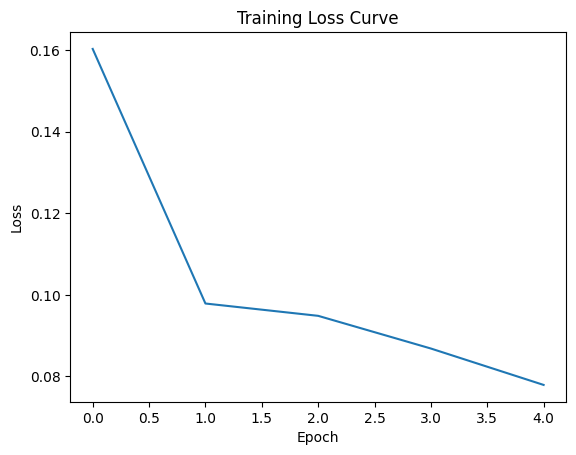

In [43]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [44]:
plt.savefig("../results/resnet_loss_data1.png")

<Figure size 640x480 with 0 Axes>

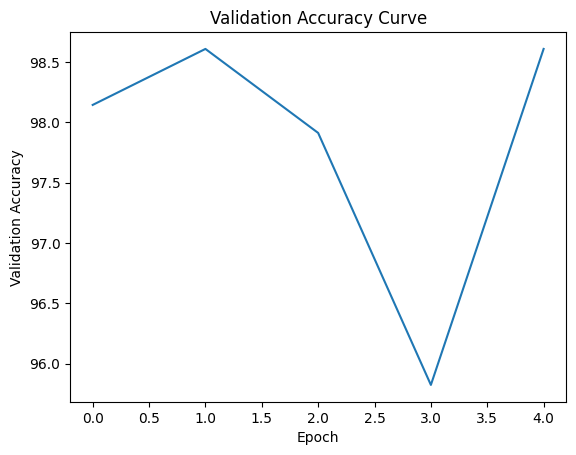

In [45]:
plt.plot(val_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title("Validation Accuracy Curve")

plt.show()

In [46]:
plt.savefig("../results/resnet_acc_data1.png")

<Figure size 640x480 with 0 Axes>